# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать двухслойную полносвязную нейронную сеть для классификации данных из лабораторной работы 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
np.random.seed(42)


def rel_error(x, y):
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.680272093239262e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447646e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


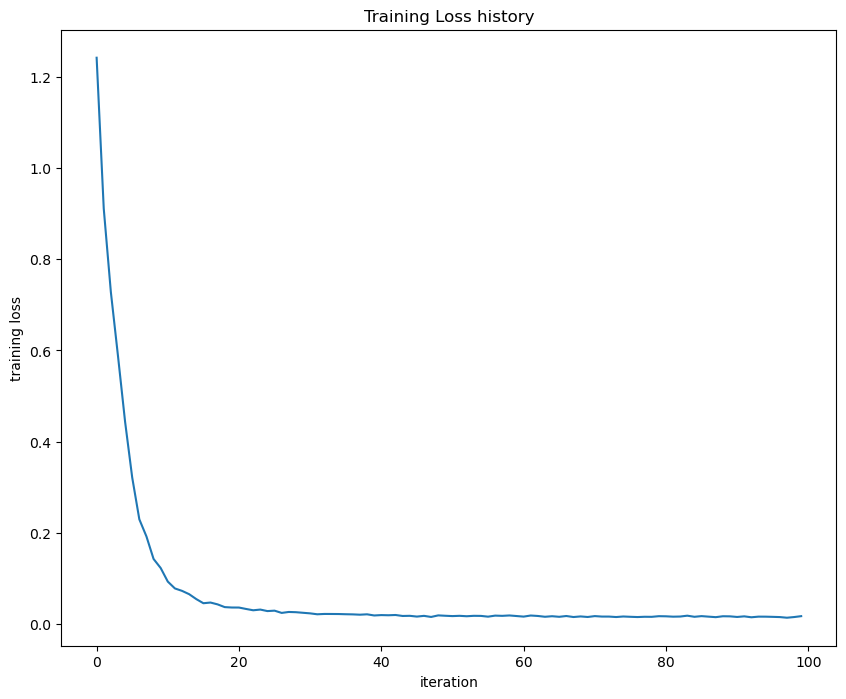

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (MNIST)

Загрузите набор данных, соответствующий вашему варианту.

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1.

Обучите нейронную сеть на ваших данных.

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [7]:
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1).astype(np.float64)
y = digits.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

mean_image = np.mean(X_train, axis=0)
X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

results = {}
best_val_acc = -1
best_test_acc = -1
best_stats = None
best_net = None
best_config = None

hidden_sizes = [64, 128, 256]
learning_rates = [5e-2, 1e-1]
regularization_strengths = [1e-4, 1e-3]
num_iters_options = [2000, 2500]

for hidden_size in hidden_sizes:
    for learning_rate in learning_rates:
        for reg in regularization_strengths:
            for num_iters in num_iters_options:
                np.random.seed(42)
                candidate_net = TwoLayerNet(64, hidden_size, 10)
                candidate_stats = candidate_net.train(
                    X_train,
                    y_train,
                    X_val,
                    y_val,
                    learning_rate=learning_rate,
                    learning_rate_decay=0.95,
                    reg=reg,
                    num_iters=num_iters,
                    batch_size=128,
                    verbose=False,
                )
                train_acc = (candidate_net.predict(X_train) == y_train).mean()
                val_acc = (candidate_net.predict(X_val) == y_val).mean()
                test_acc = (candidate_net.predict(X_test) == y_test).mean()
                config = (hidden_size, learning_rate, reg, num_iters)
                results[config] = (train_acc, val_acc, test_acc)
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_test_acc = test_acc
                    best_stats = candidate_stats
                    best_net = candidate_net
                    best_config = config

net = best_net
stats = best_stats
hidden_size, learning_rate, reg, num_iters = best_config

print('Best config: hidden_size=%d learning_rate=%f reg=%f num_iters=%d' % best_config)
print('Best validation accuracy: ', best_val_acc)
print('Test accuracy: ', best_test_acc)

Train data shape:  (1149, 64)
Train labels shape:  (1149,)
Validation data shape:  (288, 64)
Validation labels shape:  (288,)
Test data shape:  (360, 64)
Test labels shape:  (360,)
Best config: hidden_size=128 learning_rate=0.050000 reg=0.000100 num_iters=2000
Best validation accuracy:  0.9791666666666666
Test accuracy:  0.9694444444444444


Проведите настройку гиперпараметров для увеличения accuracy на валидационной выборке.

В этом задании изменялись размер скрытого слоя, скорость обучения, коэффициент регуляризации и число итераций. Для лучшей модели вычислите accuracy на тестовой выборке и проанализируйте графики изменения loss и accuracy.

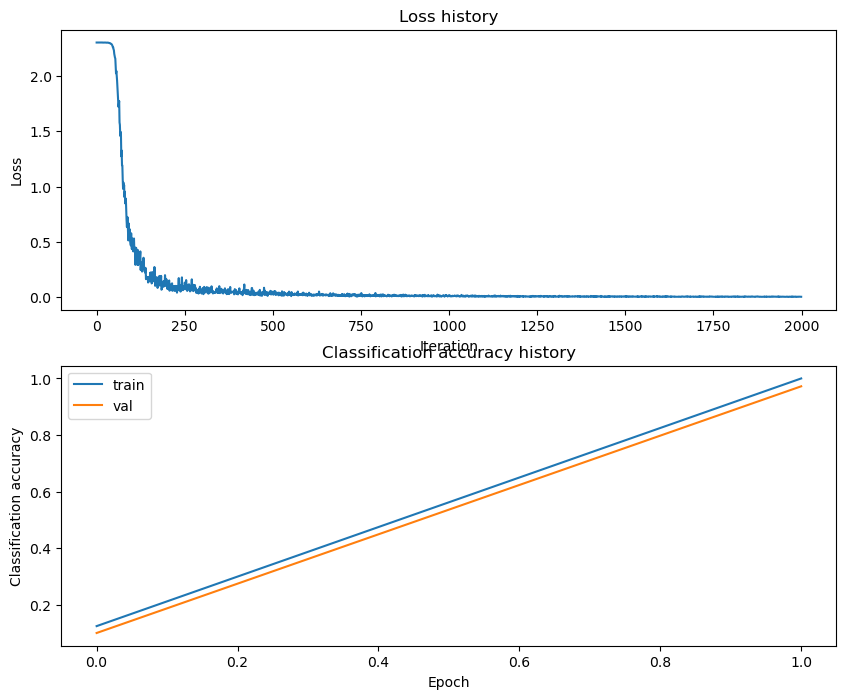

In [8]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

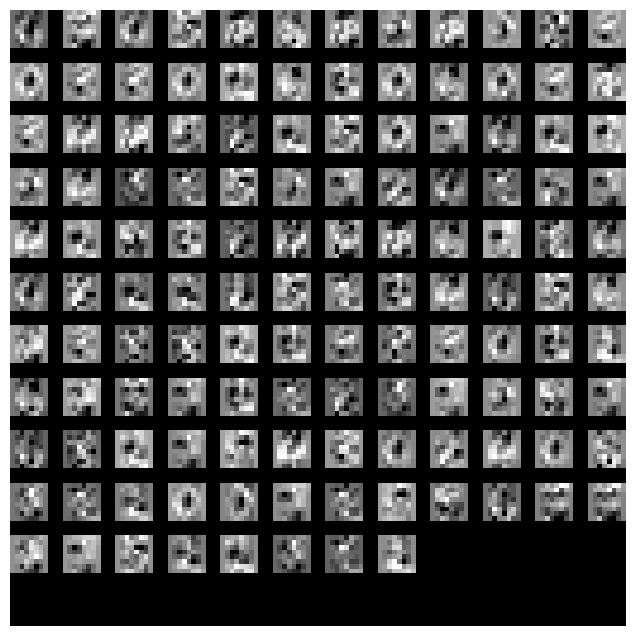

In [9]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1'].T.reshape(-1, 8, 8, 1)
    grid = visualize_grid(W1, padding=3)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.squeeze(), cmap='gray')
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

По результатам лабораторной работы была реализована и проверена двухслойная полносвязная нейронная сеть. На модельных данных прямой проход, вычисление функции потерь и обратное распространение ошибки показали очень малую погрешность, что подтверждает корректность реализации.

На реальном наборе MNIST сеть после предобработки данных и настройки гиперпараметров показала высокое качество классификации. Лучшая конфигурация позволила получить accuracy на валидационной выборке около 0.9792 и accuracy на тестовой выборке около 0.9694. Это показывает, что двухслойная нейронная сеть успешно решает задачу распознавания рукописных цифр, а подбор гиперпараметров заметно влияет на итоговое качество модели.